# Thử nghiệm với các model Deep Learning

Mục tiêu là huấn luyện 3 kiến trúc phù hợp dữ liệu dạng bảng và mất cân bằng lớp:

- **MLP**: baseline mạnh, đơn giản cho tabular features đã scale/one-hot.
- **FT-Transformer**: tokenizer từng feature thành token rồi dùng Transformer Encoder.
- **TabTransformer**: dùng Transformer cho categorical/binary tokens, rồi kết hợp với continuous features.

Mất cân bằng lớp được xử lý bằng `pos_weight` trong `BCEWithLogitsLoss` hoặc `FocalLoss`, sau đó tune threshold trên validation set để tối ưu `val_f1`.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "Notebook này cần PyTorch. Hãy chạy: pip install -r ../requirements.txt"
    ) from exc

sns.set_theme(style='whitegrid')
SEED = 42

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


reset_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

## 1. Load dữ liệu processed

In [2]:
TRAIN_PATH = Path('../data/processed/train_data.csv')
VAL_PATH = Path('../data/processed/validation_data.csv')
TEST_PATH = Path('../data/processed/test_data.csv')

MODEL_DIR = Path('../models/dl')
METRIC_DIR = Path('../results/metrics')
FIGURE_DIR = Path('../figures/models')
for directory in [MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET = 'depression_label'

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

feature_cols = [col for col in train_df.columns if col != TARGET]

print('Train:', train_df.shape, train_df[TARGET].value_counts().to_dict())
print('Validation:', val_df.shape, val_df[TARGET].value_counts().to_dict())
print('Test:', test_df.shape, test_df[TARGET].value_counts().to_dict())
print('Features:', len(feature_cols))
train_df.head()

Train: (2590, 19) {0: 2159, 1: 431}
Validation: (555, 19) {0: 463, 1: 92}
Test: (555, 19) {0: 463, 1: 92}
Features: 18


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,platform_Both,platform_Instagram,platform_Other,platform_TikTok,sm_sleep_ratio,screen_sleep_ratio,heavy_sm_user,low_sleep,depression_label
0,-1.474207,0,1.492680,1.462525,0.386499,0.576427,-0.511030,0.002328,1.152462,1.579516,1,0,0,0,0.385484,-0.274718,1,0,0
1,1.014417,1,0.898866,-1.760734,1.642517,-1.628353,-0.340194,-1.228338,1.486274,1.579516,0,1,0,0,1.685879,2.730240,1,1,1
2,-0.478757,0,0.651443,-0.149104,-0.171731,-0.799356,-0.340194,0.002328,1.486274,1.242168,0,0,0,1,0.416277,-0.190840,0,0,0
3,0.516692,1,0.849381,-0.997330,0.386499,1.581807,1.197329,0.002328,0.484839,-0.781917,1,0,0,0,1.028599,0.695086,0,1,0
4,-0.478757,1,1.096804,-1.166976,-1.009077,-1.487247,-1.365210,0.002328,1.486274,1.579516,0,1,0,0,1.379210,-0.587976,1,1,1


In [3]:
def make_xy(df):
    X = df[feature_cols].astype('float32').values
    y = df[TARGET].astype('float32').values
    return X, y


X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
pos_weight_value = neg_count / max(pos_count, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
focal_alpha = neg_count / max(neg_count + pos_count, 1)

categorical_cols = [
    col for col in feature_cols
    if set(train_df[col].dropna().unique()).issubset({0, 1})
]
continuous_cols = [col for col in feature_cols if col not in categorical_cols]
categorical_idx = [feature_cols.index(col) for col in categorical_cols]
continuous_idx = [feature_cols.index(col) for col in continuous_cols]

print(f'Positive class weight: {pos_weight_value:.3f}')
print(f'Focal alpha for positive class: {focal_alpha:.3f}')
print(f'Categorical/binary features ({len(categorical_cols)}): {categorical_cols}')
print(f'Continuous features ({len(continuous_cols)}): {continuous_cols}')

def make_loader(X, y, batch_size=128, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def make_weighted_loader(X, y, sample_weight, batch_size=128, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(sample_weight, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train, y_train, shuffle=True)
train_eval_loader = make_loader(X_train, y_train, shuffle=False)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)


Positive class weight: 5.009
Focal alpha for positive class: 0.834
Categorical/binary features (7): ['gender', 'platform_Both', 'platform_Instagram', 'platform_Other', 'platform_TikTok', 'heavy_sm_user', 'low_sleep']
Continuous features (11): ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'sm_sleep_ratio', 'screen_sleep_ratio']


## 2. Metrics, threshold tuning và training loop

In [4]:
def predict_proba(model, loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb).squeeze(1)
            probs.append(torch.sigmoid(logits).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)

In [5]:
def find_best_threshold(y_true, y_prob, preferred_threshold=None, max_f1_drop=0.003):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_prob >= threshold).astype(int)
        rows.append({
            'threshold': threshold,
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'minority_recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            'minority_precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        })
    threshold_df = pd.DataFrame(rows)
    ranked = threshold_df.sort_values(
        ['f1', 'macro_f1', 'minority_recall'], ascending=False
    )
    best = ranked.iloc[0]

    if preferred_threshold is not None:
        near_best = threshold_df[threshold_df['f1'] >= best['f1'] - max_f1_drop].copy()
        near_best['threshold_distance'] = (near_best['threshold'] - preferred_threshold).abs()
        best = near_best.sort_values(
            ['threshold_distance', 'f1', 'macro_f1'], ascending=[True, False, False]
        ).iloc[0]
    return float(best['threshold']), threshold_df


In [6]:
def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'minority_recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

In [7]:
def smooth_binary_targets(targets, label_smoothing=0.0):
    if label_smoothing <= 0:
        return targets
    return targets * (1 - label_smoothing) + 0.5 * label_smoothing


class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight.detach().clone() if pos_weight is not None else None)
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets, sample_weight=None):
        targets = smooth_binary_targets(targets, self.label_smoothing)
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction='none',
        )
        if sample_weight is not None:
            loss = loss * sample_weight
            return loss.sum() / sample_weight.sum().clamp_min(1e-8)
        return loss.mean()


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets, sample_weight=None):
        smoothed_targets = smooth_binary_targets(targets, self.label_smoothing)
        bce = nn.functional.binary_cross_entropy_with_logits(logits, smoothed_targets, reduction='none')
        pt = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        if sample_weight is not None:
            loss = loss * sample_weight
            return loss.sum() / sample_weight.sum().clamp_min(1e-8)
        return loss.mean()


In [8]:
def criterion_loss(criterion, logits, targets, sample_weight=None):
    try:
        return criterion(logits, targets, sample_weight=sample_weight)
    except TypeError:
        return criterion(logits, targets)


def unpack_batch(batch):
    if len(batch) == 3:
        xb, yb, wb = batch
        return xb, yb, wb
    xb, yb = batch
    return xb, yb, None


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    lr=1e-3,
    epochs=120,
    patience=18,
    log_every_steps=10,
    monitor='val_f1',
    preferred_threshold=None,
):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    best_state = None
    best_score = -np.inf if monitor == 'val_f1' else np.inf
    wait = 0
    history = []
    step_history = []
    global_step = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_idx, batch in enumerate(train_loader, start=1):
            global_step += 1
            xb, yb, wb = unpack_batch(batch)
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            wb = wb.to(DEVICE) if wb is not None else None
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion_loss(criterion, logits, yb, sample_weight=wb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            step_loss = float(loss.item())
            train_losses.append(step_loss)
            step_history.append({
                'epoch': epoch,
                'batch': batch_idx,
                'global_step': global_step,
                'train_step_loss': step_loss,
            })
            if log_every_steps and global_step % log_every_steps == 0:
                print(f'epoch={epoch:03d} step={global_step:04d} train_step_loss={step_loss:.4f}')

        model.eval()
        val_losses, val_probs, val_labels = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                xb, yb, wb = unpack_batch(batch)
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                wb = wb.to(DEVICE) if wb is not None else None
                logits = model(xb).squeeze(1)
                val_losses.append(float(criterion_loss(criterion, logits, yb, sample_weight=wb).item()))
                val_probs.append(torch.sigmoid(logits).cpu().numpy())
                val_labels.append(yb.cpu().numpy())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        val_prob = np.concatenate(val_probs)
        val_true = np.concatenate(val_labels)
        epoch_threshold, _ = find_best_threshold(
            val_true,
            val_prob,
            preferred_threshold=preferred_threshold,
        )
        val_metrics = compute_metrics(val_true, val_prob, epoch_threshold)
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1': val_metrics['f1'],
            'val_precision': val_metrics['precision'],
            'val_recall': val_metrics['recall'],
            'val_threshold': epoch_threshold,
        })
        print(
            f"epoch={epoch:03d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"val_f1={val_metrics['f1']:.4f} threshold={epoch_threshold:.3f}"
        )

        current_score = val_metrics['f1'] if monitor == 'val_f1' else val_loss
        improved = current_score > best_score + 1e-4 if monitor == 'val_f1' else current_score < best_score - 1e-4
        if improved:
            best_score = current_score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), pd.DataFrame(step_history)


## 3. Model definitions

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64, 32), dropout=0.25):
        super().__init__()
        layers = [nn.BatchNorm1d(input_dim)]
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [10]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.zeros(n_features, d_token))
        self.feature_embedding = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.xavier_uniform_(self.weight)
        nn.init.xavier_uniform_(self.feature_embedding)

    def forward(self, x):
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0) + self.feature_embedding.unsqueeze(0)


In [11]:
class FTTransformerClassifier(nn.Module):
    def __init__(self, n_features, d_token=64, n_heads=4, n_layers=3, dropout=0.15):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_token * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, 1),
        )
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):
        tokens = self.tokenizer(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        encoded = self.encoder(tokens)
        return self.head(encoded[:, 0])

## 4. Train MLP, FT-Transformer

Phần này chạy đủ 3 kiến trúc deep learning cho dữ liệu bảng:

- `MLP`: dùng toàn bộ feature processed như vector đầu vào.
- `FTTransformer`: tokenize từng feature thành token rồi học tương tác bằng Transformer Encoder.


Mỗi kiến trúc được chạy với 2 loss function để xử lý mất cân bằng lớp:

- `Weighted BCE`: `BCEWithLogitsLoss(pos_weight=...)`, tăng trọng số cho positive class.
- `Focal Loss`: tập trung mạnh hơn vào các sample khó, dùng `alpha` theo tỷ lệ lớp positive và `gamma=2.0`.

Tổng cộng có 6 experiment:

- `MLP|Weighted BCE`
- `MLP|Focal Loss`
- `FTTransformer|Weighted BCE`
- `FTTransformer|Focal Loss`

Trong lúc train, notebook log `train_step_loss` mỗi 10 step và `train_loss`/`val_loss` mỗi epoch. Sau khi train từng model, threshold được tune trên validation set theo `val_f1`; `val_macro_f1` và `minority_recall` chỉ dùng để theo dõi thêm.

In [12]:
histories = {}
step_histories = {}
trained_models = {}
val_rows = []
LOG_EVERY_STEPS = 50


def run_experiment(
    name,
    model,
    criterion,
    lr,
    epochs=120,
    patience=20,
    preferred_threshold=None,
    train_loader_override=None,
    monitor='val_f1',
):
    print(f'\nTraining {name}')
    active_train_loader = train_loader_override if train_loader_override is not None else train_loader
    model, history, step_history = train_model(
        model,
        active_train_loader,
        val_loader,
        criterion,
        lr=lr,
        epochs=epochs,
        patience=patience,
        log_every_steps=LOG_EVERY_STEPS,
        monitor=monitor,
        preferred_threshold=preferred_threshold,
    )
    val_prob, val_true = predict_proba(model, val_loader)
    best_threshold, threshold_df = find_best_threshold(val_true, val_prob, preferred_threshold=preferred_threshold)
    metrics = compute_metrics(val_true, val_prob, best_threshold)
    metrics.update({
        'candidate': name,
        'model': name.split('|')[0],
        'strategy': name.split('|')[1],
        'val_f1': metrics['f1'],
        'val_macro_f1': metrics['macro_f1'],
        'monitor': monitor,
    })
    val_rows[:] = [row for row in val_rows if row['candidate'] != name]
    val_rows.append(metrics)
    histories[name] = history
    step_histories[name] = step_history
    trained_models[name] = {'model': model, 'threshold_df': threshold_df, 'threshold': best_threshold, 'monitor': monitor}
    print(
        f"Best threshold={best_threshold:.3f}, val_f1={metrics['val_f1']:.4f}, "
        f"val_macro_f1={metrics['val_macro_f1']:.4f}, minority_recall={metrics['minority_recall']:.4f}"
    )
    return pd.DataFrame([metrics])


In [13]:
reset_seed(SEED)
run_experiment(
    'MLP|Weighted BCE',
    MLPClassifier(input_dim=X_train.shape[1], hidden_dims=(128, 64, 32), dropout=0.25),
    SmoothBCEWithLogitsLoss(pos_weight=pos_weight, label_smoothing=0.0),
    lr=5e-4,
)



Training MLP|Weighted BCE
epoch=001 train_loss=0.9597 val_loss=0.8794 val_f1=0.7029 threshold=0.580
epoch=002 train_loss=0.7313 val_loss=0.6799 val_f1=0.7523 threshold=0.755
epoch=003 step=0050 train_step_loss=0.6211
epoch=003 train_loss=0.6594 val_loss=0.6260 val_f1=0.7500 threshold=0.825
epoch=004 train_loss=0.6248 val_loss=0.5961 val_f1=0.7489 threshold=0.805
epoch=005 step=0100 train_step_loss=0.7368
epoch=005 train_loss=0.5875 val_loss=0.5710 val_f1=0.7593 threshold=0.805
epoch=006 train_loss=0.5762 val_loss=0.5751 val_f1=0.7580 threshold=0.835
epoch=007 train_loss=0.5682 val_loss=0.5490 val_f1=0.7568 threshold=0.805
epoch=008 step=0150 train_step_loss=0.5741
epoch=008 train_loss=0.5497 val_loss=0.5558 val_f1=0.7650 threshold=0.855
epoch=009 train_loss=0.5389 val_loss=0.5377 val_f1=0.7671 threshold=0.815
epoch=010 step=0200 train_step_loss=0.6622
epoch=010 train_loss=0.5277 val_loss=0.5153 val_f1=0.7706 threshold=0.800
epoch=011 train_loss=0.5162 val_loss=0.5085 val_f1=0.7685 thr

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.805,0.917117,0.91984,0.685484,0.923913,0.787037,0.867791,0.923913,0.952766,MLP|Weighted BCE,MLP,Weighted BCE,0.787037,0.867791,val_f1


In [14]:
reset_seed(SEED)
run_experiment(
    'MLP|Focal Loss',
    MLPClassifier(input_dim=X_train.shape[1], hidden_dims=(128, 64, 32), dropout=0.25),
    FocalLossWithLogits(alpha=0.65, gamma=1.5),
    lr=5e-4,
)



Training MLP|Focal Loss
epoch=001 train_loss=0.0910 val_loss=0.0768 val_f1=0.6844 threshold=0.540
epoch=002 train_loss=0.0740 val_loss=0.0689 val_f1=0.7297 threshold=0.590
epoch=003 step=0050 train_step_loss=0.0663
epoch=003 train_loss=0.0689 val_loss=0.0652 val_f1=0.7304 threshold=0.560
epoch=004 train_loss=0.0651 val_loss=0.0618 val_f1=0.7397 threshold=0.580
epoch=005 step=0100 train_step_loss=0.0691
epoch=005 train_loss=0.0607 val_loss=0.0590 val_f1=0.7558 threshold=0.575
epoch=006 train_loss=0.0590 val_loss=0.0609 val_f1=0.7570 threshold=0.605
epoch=007 train_loss=0.0576 val_loss=0.0553 val_f1=0.7656 threshold=0.590
epoch=008 step=0150 train_step_loss=0.0576
epoch=008 train_loss=0.0561 val_loss=0.0557 val_f1=0.7700 threshold=0.590
epoch=009 train_loss=0.0547 val_loss=0.0527 val_f1=0.7685 threshold=0.565
epoch=010 step=0200 train_step_loss=0.0565
epoch=010 train_loss=0.0517 val_loss=0.0503 val_f1=0.7525 threshold=0.600
epoch=011 train_loss=0.0515 val_loss=0.0501 val_f1=0.7489 thres

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.53,0.915315,0.923115,0.677165,0.934783,0.785388,0.866319,0.934783,0.952531,MLP|Focal Loss,MLP,Focal Loss,0.785388,0.866319,val_f1


In [15]:
reset_seed(SEED)
run_experiment(
    'FTTransformer|Weighted BCE',
    FTTransformerClassifier(n_features=X_train.shape[1], d_token=48, n_heads=4, n_layers=2, dropout=0.25),
    SmoothBCEWithLogitsLoss(pos_weight=pos_weight, label_smoothing=0.0),
    lr=5e-4,
    preferred_threshold=0.83,
)



Training FTTransformer|Weighted BCE


C:\Users\HP\AppData\Local\Temp\ipykernel_17056\3019103638.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.8527 val_loss=0.5994 val_f1=0.7215 threshold=0.805
epoch=002 train_loss=0.5571 val_loss=0.4422 val_f1=0.7685 threshold=0.830
epoch=003 step=0050 train_step_loss=0.6147
epoch=003 train_loss=0.4910 val_loss=0.3919 val_f1=0.7768 threshold=0.880
epoch=004 train_loss=0.4413 val_loss=0.3749 val_f1=0.7822 threshold=0.830
epoch=005 step=0100 train_step_loss=0.3065
epoch=005 train_loss=0.4557 val_loss=0.3780 val_f1=0.7822 threshold=0.835
epoch=006 train_loss=0.4342 val_loss=0.3485 val_f1=0.7850 threshold=0.905
epoch=007 train_loss=0.4299 val_loss=0.3481 val_f1=0.7928 threshold=0.835
epoch=008 step=0150 train_step_loss=0.6182
epoch=008 train_loss=0.4335 val_loss=0.3653 val_f1=0.7945 threshold=0.905
epoch=009 train_loss=0.4316 val_loss=0.3865 val_f1=0.7945 threshold=0.905
epoch=010 step=0200 train_step_loss=0.3846
epoch=010 train_loss=0.4215 val_loss=0.3614 val_f1=0.7964 threshold=0.900
epoch=011 train_loss=0.3989 val_loss=0.3374 val_f1=0.7944 threshold=0.860
epoch=012 step

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.86,0.927928,0.948094,0.703125,0.978261,0.818182,0.886619,0.978261,0.95955,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE,0.818182,0.886619,val_f1


In [16]:
reset_seed(SEED)
run_experiment(
    'FTTransformer|Focal Loss',
    FTTransformerClassifier(n_features=X_train.shape[1], d_token=48, n_heads=4, n_layers=2, dropout=0.15),
    FocalLossWithLogits(alpha=0.65, gamma=1.5),
    lr=5e-4,
)



Training FTTransformer|Focal Loss


C:\Users\HP\AppData\Local\Temp\ipykernel_17056\3019103638.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.0556 val_loss=0.0406 val_f1=0.7426 threshold=0.635
epoch=002 train_loss=0.0402 val_loss=0.0335 val_f1=0.7685 threshold=0.575
epoch=003 step=0050 train_step_loss=0.0424
epoch=003 train_loss=0.0371 val_loss=0.0315 val_f1=0.7721 threshold=0.610
epoch=004 train_loss=0.0356 val_loss=0.0308 val_f1=0.7778 threshold=0.600
epoch=005 step=0100 train_step_loss=0.0313
epoch=005 train_loss=0.0364 val_loss=0.0305 val_f1=0.7757 threshold=0.610
epoch=006 train_loss=0.0356 val_loss=0.0302 val_f1=0.7841 threshold=0.510
epoch=007 train_loss=0.0337 val_loss=0.0301 val_f1=0.7860 threshold=0.515
epoch=008 step=0150 train_step_loss=0.0384
epoch=008 train_loss=0.0336 val_loss=0.0297 val_f1=0.7928 threshold=0.545
epoch=009 train_loss=0.0325 val_loss=0.0293 val_f1=0.7928 threshold=0.570
epoch=010 step=0200 train_step_loss=0.0322
epoch=010 train_loss=0.0325 val_loss=0.0286 val_f1=0.8019 threshold=0.635
epoch=011 train_loss=0.0336 val_loss=0.0296 val_f1=0.7892 threshold=0.350
epoch=012 step

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.615,0.933333,0.951333,0.72,0.978261,0.829493,0.89403,0.978261,0.960747,FTTransformer|Focal Loss,FTTransformer,Focal Loss,0.829493,0.89403,val_f1


## 4.1 Precision-focused FTTransformer variants

Các cell dưới đây thử 3 hướng để giảm false positive: label smoothing, chọn checkpoint theo `val_f1`, và hard negative mining từ train set.

In [17]:
LABEL_SMOOTHING = 0.03

reset_seed(SEED)
run_experiment(
    'FTTransformer|Weighted BCE+Label Smoothing',
    FTTransformerClassifier(n_features=X_train.shape[1], d_token=48, n_heads=4, n_layers=2, dropout=0.25),
    SmoothBCEWithLogitsLoss(pos_weight=pos_weight, label_smoothing=LABEL_SMOOTHING),
    lr=5e-4
)



Training FTTransformer|Weighted BCE+Label Smoothing


C:\Users\HP\AppData\Local\Temp\ipykernel_17056\3019103638.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch=001 train_loss=0.9086 val_loss=0.6983 val_f1=0.7215 threshold=0.810
epoch=002 train_loss=0.6667 val_loss=0.5846 val_f1=0.7742 threshold=0.790
epoch=003 step=0050 train_step_loss=0.7037
epoch=003 train_loss=0.6270 val_loss=0.5505 val_f1=0.7733 threshold=0.835
epoch=004 train_loss=0.5908 val_loss=0.5411 val_f1=0.7854 threshold=0.885
epoch=005 step=0100 train_step_loss=0.4867
epoch=005 train_loss=0.6079 val_loss=0.5523 val_f1=0.7850 threshold=0.925
epoch=006 train_loss=0.5855 val_loss=0.5281 val_f1=0.7887 threshold=0.905
epoch=007 train_loss=0.5869 val_loss=0.5275 val_f1=0.7928 threshold=0.785
epoch=008 step=0150 train_step_loss=0.7235
epoch=008 train_loss=0.5873 val_loss=0.5463 val_f1=0.7945 threshold=0.905
epoch=009 train_loss=0.5878 val_loss=0.5613 val_f1=0.7945 threshold=0.915
epoch=010 step=0200 train_step_loss=0.5561
epoch=010 train_loss=0.5772 val_loss=0.5387 val_f1=0.8018 threshold=0.930
epoch=011 train_loss=0.5663 val_loss=0.5201 val_f1=0.7945 threshold=0.795
epoch=012 step

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.23,0.931532,0.958963,0.707692,1.0,0.828829,0.893018,1.0,0.956757,FTTransformer|Weighted BCE+Label Smoothing,FTTransformer,Weighted BCE+Label Smoothing,0.828829,0.893018,val_f1


In [20]:
LABEL_SMOOTHING = 0.03

reset_seed(SEED)
run_experiment(
    'FTTransformer|Focal Loss + Label Smoothing',
    FTTransformerClassifier(n_features=X_train.shape[1], d_token=48, n_heads=4, n_layers=2, dropout=0.25),
    FocalLossWithLogits(alpha=0.65, gamma=1.5, label_smoothing=LABEL_SMOOTHING),
    lr=5e-4
)


C:\Users\HP\AppData\Local\Temp\ipykernel_17056\3019103638.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



Training FTTransformer|Focal Loss + Label Smoothing
epoch=001 train_loss=0.0623 val_loss=0.0458 val_f1=0.7333 threshold=0.615
epoch=002 train_loss=0.0428 val_loss=0.0359 val_f1=0.7590 threshold=0.620
epoch=003 step=0050 train_step_loss=0.0452
epoch=003 train_loss=0.0397 val_loss=0.0348 val_f1=0.7814 threshold=0.645
epoch=004 train_loss=0.0373 val_loss=0.0321 val_f1=0.7798 threshold=0.575
epoch=005 step=0100 train_step_loss=0.0307
epoch=005 train_loss=0.0375 val_loss=0.0316 val_f1=0.7814 threshold=0.615
epoch=006 train_loss=0.0373 val_loss=0.0321 val_f1=0.7814 threshold=0.635
epoch=007 train_loss=0.0365 val_loss=0.0340 val_f1=0.7830 threshold=0.660
epoch=008 step=0150 train_step_loss=0.0447
epoch=008 train_loss=0.0374 val_loss=0.0323 val_f1=0.7887 threshold=0.635
epoch=009 train_loss=0.0349 val_loss=0.0345 val_f1=0.7857 threshold=0.630
epoch=010 step=0200 train_step_loss=0.0358
epoch=010 train_loss=0.0356 val_loss=0.0312 val_f1=0.7925 threshold=0.655
epoch=011 train_loss=0.0337 val_los

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.585,0.927928,0.948094,0.703125,0.978261,0.818182,0.886619,0.978261,0.957508,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing,0.818182,0.886619,val_f1


In [21]:
# Hard negative mining uses train predictions only. Test set is kept untouched for final evaluation.
current_val = pd.DataFrame(val_rows).sort_values('val_f1', ascending=False)
base_candidates = current_val[current_val['candidate'].str.startswith('FTTransformer')]['candidate'].tolist()
base_name = base_candidates[0]
base_model = trained_models[base_name]['model']
base_threshold = float(trained_models[base_name]['threshold'])

train_prob, train_true = predict_proba(base_model, train_eval_loader)
negative_train_mask = train_true == 0
hard_negative_cutoff = max(base_threshold, float(np.quantile(train_prob[negative_train_mask], 0.85)))
hard_negative_mask = negative_train_mask & (train_prob >= hard_negative_cutoff)

sample_weight = np.ones_like(train_true, dtype='float32')
sample_weight[hard_negative_mask] = 2.5

In [22]:
hard_negative_train_loader = make_weighted_loader(
    X_train,
    y_train,
    sample_weight=sample_weight,
    batch_size=128,
    shuffle=True,
)

hnm_pos_weight = torch.tensor([pos_weight_value * 0.65], dtype=torch.float32, device=DEVICE)
print(
    f'Base for HNM: {base_name} | hard negatives: {hard_negative_mask.sum()} '
    f'/ {negative_train_mask.sum()} | cutoff={hard_negative_cutoff:.3f} | pos_weight={hnm_pos_weight.item():.3f}'
)

reset_seed(SEED + 7)


Base for HNM: FTTransformer|Focal Loss | hard negatives: 170 / 2159 | cutoff=0.615 | pos_weight=3.256


In [23]:
run_experiment(
    'FTTransformer|Weighted BCE+LS+Hard Negative Mining',
    FTTransformerClassifier(n_features=X_train.shape[1], d_token=48, n_heads=4, n_layers=2, dropout=0.25),
    SmoothBCEWithLogitsLoss(pos_weight=hnm_pos_weight, label_smoothing=LABEL_SMOOTHING),
    lr=5e-4,
    train_loader_override=hard_negative_train_loader,
)

C:\Users\HP\AppData\Local\Temp\ipykernel_17056\3019103638.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



Training FTTransformer|Weighted BCE+LS+Hard Negative Mining
epoch=001 train_loss=0.8302 val_loss=0.5553 val_f1=0.7313 threshold=0.625
epoch=002 train_loss=0.6464 val_loss=0.4644 val_f1=0.7593 threshold=0.755
epoch=003 step=0050 train_step_loss=0.5786
epoch=003 train_loss=0.5996 val_loss=0.5140 val_f1=0.7407 threshold=0.730
epoch=004 train_loss=0.5907 val_loss=0.4648 val_f1=0.7778 threshold=0.770
epoch=005 step=0100 train_step_loss=0.5572
epoch=005 train_loss=0.5842 val_loss=0.4555 val_f1=0.7778 threshold=0.770
epoch=006 train_loss=0.5681 val_loss=0.4490 val_f1=0.7830 threshold=0.645
epoch=007 train_loss=0.5612 val_loss=0.4465 val_f1=0.7810 threshold=0.715
epoch=008 step=0150 train_step_loss=0.5179
epoch=008 train_loss=0.5682 val_loss=0.4390 val_f1=0.7826 threshold=0.750
epoch=009 train_loss=0.5558 val_loss=0.4337 val_f1=0.7867 threshold=0.755
epoch=010 step=0200 train_step_loss=0.5129
epoch=010 train_loss=0.5748 val_loss=0.4360 val_f1=0.7925 threshold=0.715
epoch=011 train_loss=0.5480

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.595,0.92973,0.944819,0.712,0.967391,0.820276,0.888302,0.967391,0.959409,FTTransformer|Weighted BCE+LS+Hard Negative Mi...,FTTransformer,Weighted BCE+LS+Hard Negative Mining,0.820276,0.888302,val_f1


In [24]:
run_experiment(
    'FTTransformer|Focal Loss + Label Smoothing + Hard Negative Mining',
    FTTransformerClassifier(n_features=X_train.shape[1], d_token=48, n_heads=4, n_layers=2, dropout=0.25),
    FocalLossWithLogits(alpha=0.65, gamma=1.5, label_smoothing=LABEL_SMOOTHING),
    lr=5e-4,
    train_loader_override=hard_negative_train_loader,
)

C:\Users\HP\AppData\Local\Temp\ipykernel_17056\3019103638.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



Training FTTransformer|Focal Loss + Label Smoothing + Hard Negative Mining
epoch=001 train_loss=0.0741 val_loss=0.0450 val_f1=0.7524 threshold=0.410
epoch=002 train_loss=0.0513 val_loss=0.0349 val_f1=0.7783 threshold=0.470
epoch=003 step=0050 train_step_loss=0.0572
epoch=003 train_loss=0.0485 val_loss=0.0348 val_f1=0.7818 threshold=0.485
epoch=004 train_loss=0.0462 val_loss=0.0343 val_f1=0.7818 threshold=0.555
epoch=005 step=0100 train_step_loss=0.0405
epoch=005 train_loss=0.0450 val_loss=0.0325 val_f1=0.7838 threshold=0.485
epoch=006 train_loss=0.0452 val_loss=0.0349 val_f1=0.7798 threshold=0.550
epoch=007 train_loss=0.0461 val_loss=0.0327 val_f1=0.7857 threshold=0.470
epoch=008 step=0150 train_step_loss=0.0382
epoch=008 train_loss=0.0449 val_loss=0.0333 val_f1=0.7757 threshold=0.540
epoch=009 train_loss=0.0445 val_loss=0.0330 val_f1=0.7873 threshold=0.500
epoch=010 step=0200 train_step_loss=0.0423
epoch=010 train_loss=0.0446 val_loss=0.0329 val_f1=0.7873 threshold=0.525
epoch=011 tr

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
0,0.54,0.92973,0.953529,0.705426,0.98913,0.823529,0.88983,0.98913,0.95678,FTTransformer|Focal Loss + Label Smoothing + H...,FTTransformer,Focal Loss + Label Smoothing + Hard Negative M...,0.823529,0.88983,val_f1


In [25]:
dl_epoch_loss_log = pd.concat(
    [df.assign(candidate=name) for name, df in histories.items()], ignore_index=True
)
dl_step_loss_log = pd.concat(
    [df.assign(candidate=name) for name, df in step_histories.items()], ignore_index=True
)
dl_epoch_loss_log.to_csv(METRIC_DIR / 'dl_epoch_loss_log.csv', index=False)
dl_step_loss_log.to_csv(METRIC_DIR / 'dl_step_loss_log.csv', index=False)

dl_validation_metrics = (
    pd.DataFrame(val_rows)
    .sort_values('val_f1', ascending=False)
    .drop_duplicates('candidate', keep='first')
)
dl_validation_metrics.to_csv(METRIC_DIR / 'dl_validation_metrics.csv', index=False)
dl_validation_metrics


,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy,val_f1,val_macro_f1,monitor
3,0.615,0.933333,0.951333,0.720000,0.978261,0.829493,0.894030,0.978261,0.960747,FTTransformer|Focal Loss,FTTransformer,Focal Loss,0.829493,0.894030,val_f1
4,0.230,0.931532,0.958963,0.707692,1.000000,0.828829,0.893018,1.000000,0.956757,FTTransformer|Weighted BCE+Label Smoothing,FTTransformer,Weighted BCE+Label Smoothing,0.828829,0.893018,val_f1
7,0.540,0.929730,0.953529,0.705426,0.989130,0.823529,0.889830,0.989130,0.956780,FTTransformer|Focal Loss + Label Smoothing + H...,FTTransformer,Focal Loss + Label Smoothing + Hard Negative M...,0.823529,0.889830,val_f1
6,0.595,0.929730,0.944819,0.712000,0.967391,0.820276,0.888302,0.967391,0.959409,FTTransformer|Weighted BCE+LS+Hard Negative Mi...,FTTransformer,Weighted BCE+LS+Hard Negative Mining,0.820276,0.888302,val_f1
2,0.860,0.927928,0.948094,0.703125,0.978261,0.818182,0.886619,0.978261,0.959550,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE,0.818182,0.886619,val_f1
5,0.585,0.927928,0.948094,0.703125,0.978261,0.818182,0.886619,0.978261,0.957508,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing,0.818182,0.886619,val_f1
0,0.805,0.917117,0.919840,0.685484,0.923913,0.787037,0.867791,0.923913,0.952766,MLP|Weighted BCE,MLP,Weighted BCE,0.787037,0.867791,val_f1
1,0.530,0.915315,0.923115,0.677165,0.934783,0.785388,0.866319,0.934783,0.952531,MLP|Focal Loss,MLP,Focal Loss,0.785388,0.866319,val_f1


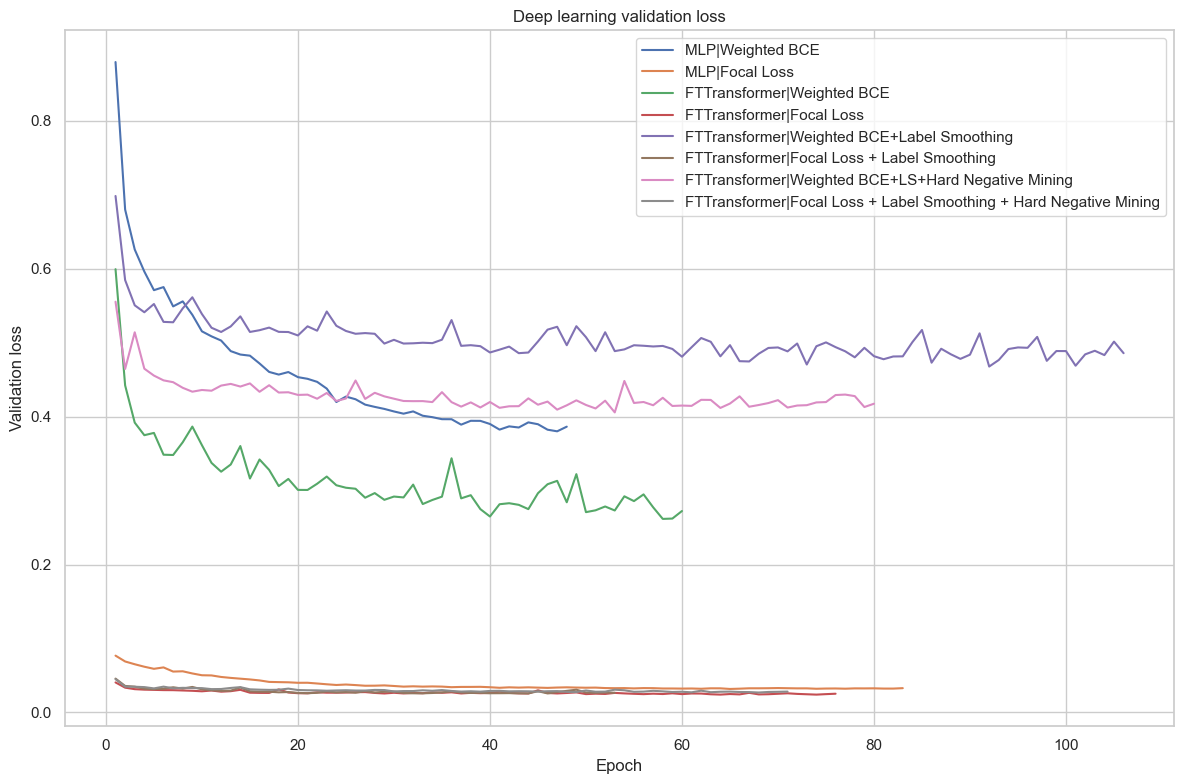

In [27]:
plt.figure(figsize=(12, 8))
for name, history in histories.items():
    plt.plot(history['epoch'], history['val_loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Deep learning validation loss')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'dl_validation_loss.png', dpi=160)
plt.show()

## 5. Đánh giá test set và export model tốt nhất

In [28]:
test_rows = []
reports = {}

for name, pack in trained_models.items():
    model = pack['model']
    threshold = pack['threshold']
    test_prob, test_true = predict_proba(model, test_loader)
    metrics = compute_metrics(test_true, test_prob, threshold)
    metrics.update({'candidate': name, 'model': name.split('|')[0], 'strategy': name.split('|')[1]})
    test_rows.append(metrics)

    test_pred = (test_prob >= threshold).astype(int)
    reports[name] = classification_report(test_true, test_pred, output_dict=True, zero_division=0)

dl_test_metrics = pd.DataFrame(test_rows).sort_values('f1', ascending=False)
dl_test_metrics.to_csv(METRIC_DIR / 'dl_test_metrics.csv', index=False)
dl_test_metrics

,threshold,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,minority_recall,roc_auc,candidate,model,strategy
4,0.230,0.920721,0.943774,0.681818,0.978261,0.803571,0.876955,0.978261,0.954245,FTTransformer|Weighted BCE+Label Smoothing,FTTransformer,Weighted BCE+Label Smoothing
7,0.540,0.918919,0.920920,0.691057,0.923913,0.790698,0.870209,0.923913,0.954198,FTTransformer|Focal Loss + Label Smoothing + H...,FTTransformer,Focal Loss + Label Smoothing + Hard Negative M...
2,0.860,0.915315,0.923115,0.677165,0.934783,0.785388,0.866319,0.934783,0.950136,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE
5,0.585,0.911712,0.912245,0.672000,0.913043,0.774194,0.859661,0.913043,0.955770,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing
3,0.615,0.908108,0.905731,0.664000,0.902174,0.764977,0.853933,0.902174,0.954268,FTTransformer|Focal Loss,FTTransformer,Focal Loss
6,0.595,0.906306,0.900296,0.661290,0.891304,0.759259,0.850547,0.891304,0.950441,FTTransformer|Weighted BCE+LS+Hard Negative Mi...,FTTransformer,Weighted BCE+LS+Hard Negative Mining
0,0.805,0.897297,0.868767,0.649573,0.826087,0.727273,0.832005,0.826087,0.944619,MLP|Weighted BCE,MLP,Weighted BCE
1,0.530,0.895495,0.867687,0.644068,0.826087,0.723810,0.829683,0.826087,0.946826,MLP|Focal Loss,MLP,Focal Loss


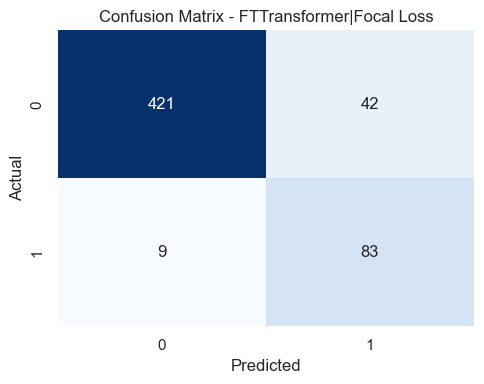

{'model_name': 'FTTransformer|Focal Loss',
 'feature_cols': ['age',
  'gender',
  'daily_social_media_hours',
  'sleep_hours',
  'screen_time_before_sleep',
  'academic_performance',
  'physical_activity',
  'social_interaction_level',
  'stress_level',
  'anxiety_level',
  'platform_Both',
  'platform_Instagram',
  'platform_Other',
  'platform_TikTok',
  'sm_sleep_ratio',
  'screen_sleep_ratio',
  'heavy_sm_user',
  'low_sleep'],
 'threshold': 0.615,
 'pos_weight': 5.009280742459397,
 'focal_alpha': 0.8335907335907335,
 'input_dim': 18,
 'categorical_cols': ['gender',
  'platform_Both',
  'platform_Instagram',
  'platform_Other',
  'platform_TikTok',
  'heavy_sm_user',
  'low_sleep'],
 'continuous_cols': ['age',
  'daily_social_media_hours',
  'sleep_hours',
  'screen_time_before_sleep',
  'academic_performance',
  'physical_activity',
  'social_interaction_level',
  'stress_level',
  'anxiety_level',
  'sm_sleep_ratio',
  'screen_sleep_ratio'],
 'categorical_idx': [1, 10, 11, 12, 13

In [29]:
best_name = dl_validation_metrics.iloc[0]['candidate']
best_model = trained_models[best_name]['model']
best_threshold = float(trained_models[best_name]['threshold'])

test_prob, test_true = predict_proba(best_model, test_loader)
test_pred = (test_prob >= best_threshold).astype(int)
cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'dl_best_confusion_matrix.png', dpi=160)
plt.show()

pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1']).to_csv(
    METRIC_DIR / 'dl_best_confusion_matrix.csv'
)
pd.DataFrame(classification_report(test_true, test_pred, output_dict=True, zero_division=0)).T.to_csv(
    METRIC_DIR / 'dl_best_classification_report.csv'
)

best_artifact = {
    'model_name': best_name,
    'feature_cols': feature_cols,
    'threshold': best_threshold,
    'pos_weight': pos_weight_value,
    'focal_alpha': focal_alpha,
    'input_dim': X_train.shape[1],
    'categorical_cols': categorical_cols,
    'continuous_cols': continuous_cols,
    'categorical_idx': categorical_idx,
    'continuous_idx': continuous_idx,
}

torch.save(
    {
        'state_dict': best_model.state_dict(),
        'metadata': best_artifact,
    },
    MODEL_DIR / 'best_dl_model.pt',
)

with open(MODEL_DIR / 'best_dl_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_artifact, f, indent=2)

best_artifact

In [30]:
export_rows = []
for rank, row in enumerate(dl_test_metrics.itertuples(index=False), start=1):
    export_rows.append({
        'rank': rank,
        'candidate': row.candidate,
        'model': row.model,
        'strategy': row.strategy,
        'threshold': row.threshold,
        'test_accuracy': row.accuracy,
        'test_balanced_accuracy': row.balanced_accuracy,
        'test_precision': row.precision,
        'test_recall': row.recall,
        'test_f1': row.f1,
        'test_macro_f1': row.macro_f1,
        'test_minority_recall': row.minority_recall,
        'test_roc_auc': row.roc_auc,
        'artifact_path': '../models/dl/best_dl_model.pt' if row.candidate == best_name else '',
    })

exported_top_dl_models = pd.DataFrame(export_rows)
exported_top_dl_models.to_csv(MODEL_DIR / 'exported_top_dl_models.csv', index=False)
exported_top_dl_models

,rank,candidate,model,strategy,threshold,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_macro_f1,test_minority_recall,test_roc_auc,artifact_path
0,1,FTTransformer|Weighted BCE+Label Smoothing,FTTransformer,Weighted BCE+Label Smoothing,0.230,0.920721,0.943774,0.681818,0.978261,0.803571,0.876955,0.978261,0.954245,
1,2,FTTransformer|Focal Loss + Label Smoothing + H...,FTTransformer,Focal Loss + Label Smoothing + Hard Negative M...,0.540,0.918919,0.920920,0.691057,0.923913,0.790698,0.870209,0.923913,0.954198,
2,3,FTTransformer|Weighted BCE,FTTransformer,Weighted BCE,0.860,0.915315,0.923115,0.677165,0.934783,0.785388,0.866319,0.934783,0.950136,
3,4,FTTransformer|Focal Loss + Label Smoothing,FTTransformer,Focal Loss + Label Smoothing,0.585,0.911712,0.912245,0.672000,0.913043,0.774194,0.859661,0.913043,0.955770,
4,5,FTTransformer|Focal Loss,FTTransformer,Focal Loss,0.615,0.908108,0.905731,0.664000,0.902174,0.764977,0.853933,0.902174,0.954268,../models/dl/best_dl_model.pt
5,6,FTTransformer|Weighted BCE+LS+Hard Negative Mi...,FTTransformer,Weighted BCE+LS+Hard Negative Mining,0.595,0.906306,0.900296,0.661290,0.891304,0.759259,0.850547,0.891304,0.950441,
6,7,MLP|Weighted BCE,MLP,Weighted BCE,0.805,0.897297,0.868767,0.649573,0.826087,0.727273,0.832005,0.826087,0.944619,
7,8,MLP|Focal Loss,MLP,Focal Loss,0.530,0.895495,0.867687,0.644068,0.826087,0.723810,0.829683,0.826087,0.946826,
